In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
ad = pd.read_csv("E:\\ml\\advertising.csv")

In [3]:
ad.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
ad.shape

(200, 4)

In [5]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
ad.describe([0.05 ,0.95,0.50,0.90])

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
5%,13.195000,1.995000,3.600000,6.600000
50%,149.750000,22.900000,25.750000,16.000000
90%,261.440000,43.520000,59.070000,21.710000
95%,280.735000,46.810000,71.825000,23.800000
max,296.400000,49.600000,114.000000,27.000000


# Data Cleaning

In [7]:
ad.isnull().sum()*100/ad.shape[0]

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

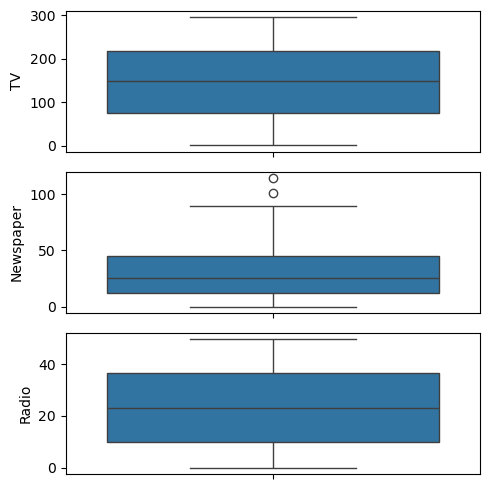

In [8]:
# Outlier Analysis
fig,axs = plt.subplots(3,figsize=(5,5))
plt1 = sns.boxplot(ad['TV'],ax=axs[0])
plt2 = sns.boxplot(ad['Newspaper'],ax=axs[1])
plt3 = sns.boxplot(ad['Radio'], ax = axs[2])
plt.tight_layout()

 There are no considerable outliers present in the data.

## Exploratory Data Analysis
Univariate Analysis
Sales (Target Variable)

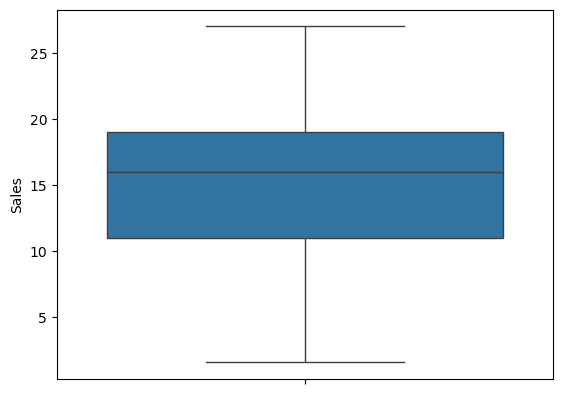

In [9]:
sns.boxplot(ad["Sales"])
plt.show()

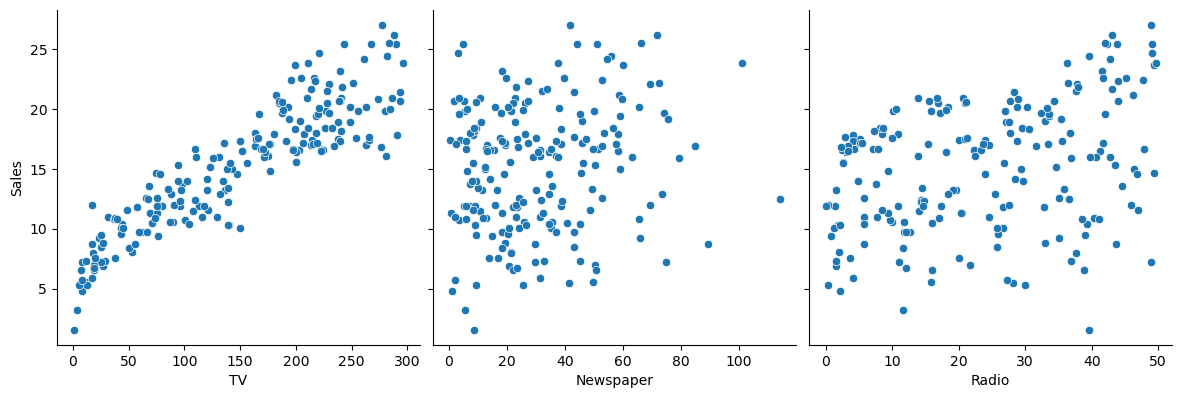

In [10]:
# Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(data=ad,x_vars=["TV","Newspaper","Radio"],y_vars="Sales",height=4,aspect=1,kind="scatter")
plt.show()

## Scatter Plot Insights

TV vs Sales (left plot)

Clear positive linear relationship.

As TV ad spending increases, Sales rise significantly.

Matches the strong correlation (0.9) from the heatmap.

Newspaper vs Sales (middle plot)

No visible pattern; points are widely scattered.

Indicates weak or no linear relationship.

Confirms the low correlation (0.16).

Radio vs Sales (right plot)

Slight upward trend, but with more spread.

Some positive association, but weaker than TV.

Matches the moderate correlation (0.35).

Overall Insights

TV advertising is the most effective medium for boosting sales — strong linear trend.

Radio has some effect, but it’s smaller and less consistent.

Newspaper advertising has little to no effect on sales — likely not cost-effective.

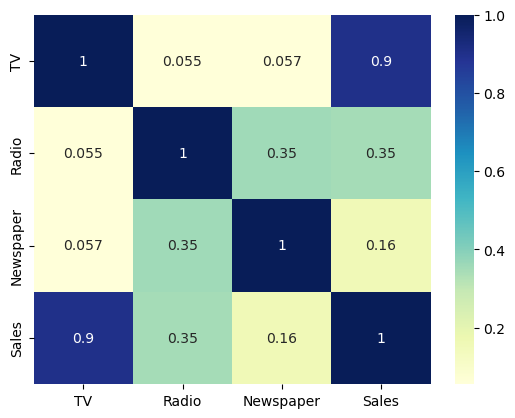

In [11]:
# Let's see the correlation between different variables.
sns.heatmap(ad.corr(),cmap="YlGnBu",annot=True)
plt.show()

## Observations from the heatmap

TV vs Sales (0.9 correlation)

Very strong positive relationship.

Suggests that increases in TV advertising are strongly associated with higher sales.

TV is likely the most influential predictor of Sales in this dataset.

Radio vs Sales (0.35 correlation)

Moderate positive relationship.

Radio has some effect on sales, but much weaker compared to TV.

Newspaper vs Sales (0.16 correlation)

Very weak correlation.

Newspaper advertising has almost no clear impact on sales.

This variable may not be a useful predictor in a regression model.

Inter-relationships among predictors

Radio & Newspaper: correlation of 0.35 → slight overlap, but not too strong.

TV & Newspaper, TV & Radio: very low correlations (≈0.05) → TV spending is independent of other channels.

📊 Insights / Business implications

TV advertising is the key driver of sales, much stronger than other channels.

Radio can help, but effect is smaller.

Newspaper ads don’t seem effective in driving sales; budget spent here may not yield strong returns.

Since predictors aren’t highly correlated with each other (except mild Radio–Newspaper), multicollinearity should not be a big issue if you fit a regression model.

## Model Building
### Performing Simple Linear Regression


Equation of linear regression
y=c+m1x1+m2x2+...+mnxn
 

y
  is the response
c
  is the intercept
m1
  is the coefficient for the first feature
mn
  is the coefficient for the nth feature
In our case:

y=c+m1×TV
 

The  m
  values are called the model coefficients or model parameters.

In [12]:
X = ad["TV"]
y = ad["Sales"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [13]:
X.head()

0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
Name: TV, dtype: float64

In [14]:
y_train.sample(10)

118    15.9
35     17.8
56      5.5
191    11.9
90     14.0
176    20.2
55     23.7
169    20.0
51     10.7
121     7.0
Name: Sales, dtype: float64

Building a Linear Model
You first need to import the statsmodel.api library using which you'll perform the linear regression.
By default, the statsmodels library fits a line on the dataset which passes through the origin. But in order to have an intercept, you need to manually use the add_constant attribute of statsmodels. And once you've added the constant to your X_train dataset, you can go ahead and fit a regression line using the OLS (Ordinary Least Squares) attribute of statsmodels as shown below

In [15]:
import statsmodels.api as sm
# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train,X_train_sm).fit()

In [16]:
# Print the parameters, i.e. the intercept and the slope of the regression line fitted
lr.params

const    6.948683
TV       0.054546
dtype: float64

Got it 👍 Let’s break down what this code does step by step:

import statsmodels.api as sm

# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

lr = sm.OLS(y_train, X_train_sm).fit()

1. sm.add_constant(X_train)

By default, statsmodels.OLS does not include an intercept term in the regression.

sm.add_constant() explicitly adds a column of 1s to your predictors (X_train).

This allows the model to estimate the intercept (β₀) along with the coefficients (β₁, β₂, …).

2. sm.OLS(y_train, X_train_sm)

sm.OLS = Ordinary Least Squares regression (a type of linear regression).

y_train: your dependent variable (Sales in your case).

X_train_sm: your independent variables (TV, Radio, Newspaper + the intercept column).

At this stage, it just sets up the model — it hasn’t fit anything yet.

3. .fit()

Actually runs the regression.

Solves for the coefficients (β values) that minimize the sum of squared residuals (the difference between actual and predicted Sales).

Stores results in lr.

4. The lr object

After fitting, lr contains the regression results.
You can check:

print(lr.summary())


This will give you:

Coefficients (β values) → effect of each variable on Sales.

p-values → significance of predictors.

R-squared / Adj. R-squared → how well the model explains Sales.

F-statistic → overall model significance.

In [17]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Wed, 17 Sep 2025   Prob (F-statistic):           1.52e-52
Time:                        07:32:01   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.0

### Ordinary Least Squares (OLS) 
It is a fundamental statistical method used in linear regression to find the best-fitting line through a set of data points. Its core principle is to minimize the sum of the squared differences between the observed values (the actual data) and the values predicted by the linear model. This minimization process identifies the optimal parameters (coefficients and intercept) for the linear equation, thereby creating a predictive model that best represents the underlying trend in the data. 

### sm.add_constant() 
is used to add the intercept to the regression.

👉 Intercept = the starting value of Sales when all ad spend is 0.

Why we need it?

If we don’t add it, the model will assume:
Sales = 0 when TV = 0, Radio = 0, Newspaper = 0
(which is not realistic).

If we add it, the model becomes:
Sales = starting point (intercept) + effect of TV + effect of Radio + effect of Newspaper

So the intercept makes the line fit the data better.

💡 Think of it like this:
When you draw a straight line on a graph, you need both:

The slope (how steep the line is → effect of ads).

The starting point (where the line cuts the y-axis → base sales).

Without add_constant(), you lose the starting point.

statsmodels.OLS by default fits a model without an intercept.
So the regression equation would look like:
This forces the line (or hyperplane) to always pass through the origin (0,0,…), which usually doesn’t make sense in real data.

With the constant

When we add the constant, the model becomes:

β₀ (intercept) represents the baseline value of 

y (Sales) when all predictors are 0.

It gives the model flexibility to fit the data better.

Looking at some key statistics from the summary
The values we are concerned with are -

1.The coefficients and significance (p-values)
2.R-squared
3.F statistic and its significance
1. The coefficient for TV is 0.054, with a very low p value
The coefficient is statistically significant. So the association is not purely by chanc

2. R - squared is 0.816
Meaning that 81.6% of the variance in Sales is explained by TV

This is a decent R-squared value.

3. F statistic has a very low p value (practically low)
Meaning that the model fit is statistically significant, and the explained variance isn't purely by chance.


The fit is significant. Let's visualize how well the model fit the data.

From the parameters that we get, our linear regression equation becomes:

Sales=6.948+0.054×TV

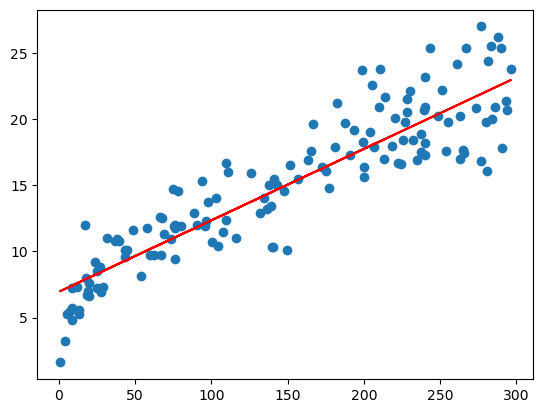

In [18]:
plt.scatter(X_train,y_train)
plt.plot(X_train,6.948+0.054*X_train,'r')
plt.show()

## Why do we care about errors being normally distributed?

In linear regression, we make some assumptions so that our results are reliable. One of the most important is:

👉 The error terms (residuals = actual − predicted) should follow a normal distribution.

Reasons why:

Valid statistical tests (t-test, F-test, p-values):

Regression uses tests to decide if predictors (like TV, Radio) are important.

These tests assume the errors are normal.

If errors are not normal, p-values and confidence intervals can be wrong → misleading conclusions.

Better confidence intervals & predictions:

Normal errors ensure that the confidence intervals around predictions are accurate.

Without normality, intervals may be too wide or too narrow.

Central Limit Theorem connection:

With large data, even if errors aren’t perfectly normal, results are usually okay (thanks to CLT).

But for smaller datasets, non-normal errors can be a problem.

Easy way to think about it:

Imagine you’re trying to predict Sales.

The model won’t be perfect → it will make mistakes (errors).

If those mistakes are random and bell-shaped (normal) → good, the model is balanced.

If those mistakes are skewed or lopsided → bad, something is wrong (maybe a missing variable, wrong model, or outliers).

✅ That’s why we plot the histogram (or a Q-Q plot) of residuals → to check if they look like a normal curve.

## P Value
1. What the F-test is testing

Null hypothesis (H₀): All regression coefficients (except the intercept) are equal to 0.
→ i.e., the model does not explain any variance beyond the mean.

Alternative hypothesis (H₁): At least one predictor has a coefficient ≠ 0.

2. Interpreting the p-value of the F-statistic

A small p-value (p < 0.05) → reject H₀ → the model is statistically significant, meaning your predictors explain a meaningful amount of variance.

A large p-value (p > 0.05) → fail to reject H₀ → the model is not significant, meaning the model’s explained variance could just be due to chance.

3. Why your statement is flipped

You said:

"if F-statistics p-value should be larger than 0.05 to satisfy H₀"

Yes, that’s correct only if we want to fail to reject H₀ (i.e., if the model has no explanatory power).

But in practice, when we fit a regression model, we usually hope to reject H₀ — we want a small p-value (e.g., < 0.05), which shows the model has predictive power beyond random chance.

✅ So to summarize:

Small p-value (F-test): Model is statistically significant → good evidence that predictors matter.

Large p-value (F-test): No evidence that the model is better than just the mean → predictors might be useless.

In [19]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train-y_train_pred)

<Figure size 640x480 with 0 Axes>

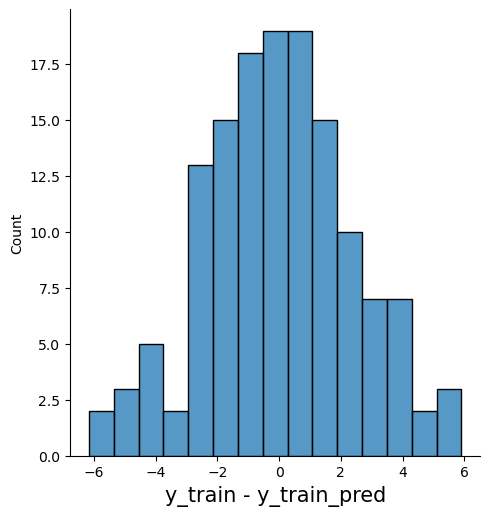

In [20]:
fig = plt.figure()
sns.displot(res,bins=15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading 
plt.xlabel('y_train - y_train_pred', fontsize = 15)         # X-label
plt.show()

The residuals are following the normally distributed with a mean 0. All good!

Looking for patterns in the residuals

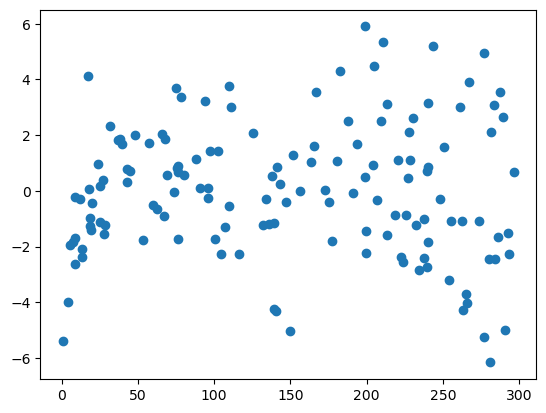

In [21]:
plt.scatter(X_train,res)
plt.show()

We are confident that the model fit isn't by chance, and has decent predictive power. The normality of residual terms allows some inference on the coefficients.

Although, the variance of residuals increasing with X indicates that there is significant variation that this model is unable to explain.

As you can see, the regression line is a pretty good fit to the data

## Predictions on the Test Set
Now that you have fitted a regression line on your train dataset, it's time to make some predictions on the test data. For this, you first need to add a constant to the X_test data like you did for X_train and then you can simply go on and predict the y values corresponding to X_test using the predict attribute of the fitted regression line

In [22]:
# Add constraint to X_test
X_train_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_Sm
y_pred = lr.predict(X_train_sm)

What does add_constant() do?

By default, statsmodels does not include an intercept in regression models.
sm.add_constant(X_test) adds a column of 1s to X_test, which represents the intercept term (β₀) in the regression equation:

Without this column of 1s, statsmodels would only estimate slopes (β₁, β₂, …), but no intercept.

2. Why do we need the intercept?

The intercept (β₀) allows the regression line/plane to shift up or down.

Without it, the model is forced to pass through the origin (0,0,…), which is usually unrealistic unless you know that when all predictors = 0, the outcome must also be 0.

Example:

Suppose you’re predicting house prices from square footage.

Without an intercept → the model assumes a house of 0 sqft has price = 0.

With an intercept → the model can predict a realistic base price.

3. Why only in statsmodels (not scikit-learn)?

scikit-learn’s LinearRegression() includes the intercept by default (fit_intercept=True).

statsmodels.OLS() does not add it automatically, so we need sm.add_constant() manually.

✅ So in your code:

X_test_sm = sm.add_constant(X_test)  
y_pred = lr.predict(X_test_sm)

In [23]:
y_pred.head()

126     7.374140
104    19.941482
99     14.323269
92     18.823294
111    20.132392
dtype: float64

In [24]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [25]:
#Returns the mean squared error; we'll take a square root
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(2.0192960089662324)

In [26]:
r_squared = r2_score(y_test, y_pred)
r_squared

0.7921031601245658

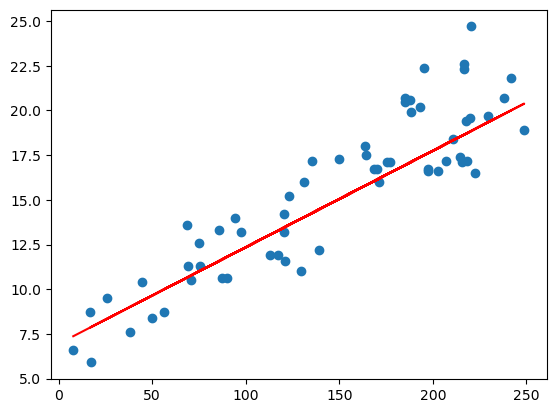

In [27]:
plt.scatter(X_test, y_test)
plt.plot(X_test, 6.948 + 0.054 * X_test, 'r')
plt.show()

## Linear Regression using Sklearn

In [28]:
from sklearn.linear_model import LinearRegression

In [33]:
X = ad[["TV"]]
y = ad["Sales"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [34]:
# Create and fit the model
lr = LinearRegression()   # by default, fit_intercept=True
lr.fit(X_train, y_train)

LinearRegression()

Rule of thumb:

Single feature → always use df[["col"]] (2D) instead of df["col"] (1D).

Multiple features → select them as a list: df[["TV", "Radio", "Newspaper"]].

X is a Pandas Series (1D). But scikit-learn expects a 2D feature matrix (shape: (n_samples, n_features)).

In [35]:
y_pred = lr.predict(X_test)

# Coefficients
print("Intercept (β₀):", lr.intercept_)
print("Coefficient (β₁):", lr.coef_)
print("Predictions:", y_pred)

# Model performance
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Intercept (β₀): 6.948683200001357
Coefficient (β₁): [0.05454575]
Predictions: [ 7.37414007 19.94148154 14.32326899 18.82329361 20.13239168 18.2287449
 14.54145201 17.72692398 18.75238413 18.77420243 13.34144544 19.46693349
 10.01415451 17.1923756  11.70507285 12.08689312 15.11418241 16.23237035
 15.8669138  13.1068987  18.65965635 14.00690363 17.60692332 16.60328147
 17.03419291 18.96511257 18.93783969 11.05597839 17.03419291 13.66326538
 10.6796127  10.71234015 13.5487193  17.22510305  9.67597085 13.52144643
 12.25053038 16.13418799 19.07965865 17.48692266 18.69783838 16.53237199
 15.92145955 18.86693021 13.5050827  11.84143724  7.87050642 20.51966653
 10.79961336  9.03233096 17.99419817 16.29237067 11.04506924 14.09963141
 18.44147334  9.3759692   7.88687015  8.34505447 17.72692398 11.62325422]
R² score: 0.7921031601245662
MSE: 4.077556371826948


### When we fit a regression model, we split the data into train and test sets:

Training set (X_train, y_train) → used to fit the model (learn coefficients).

Test set (X_test, y_test) → used to evaluate how well the model generalizes to unseen data.

Why do we need y_test in evaluation?

When you predict on the test set:

y_pred = lr.predict(X_test)


you get the model’s predicted values for those unseen inputs.
But to measure how good those predictions are, you need the true values (y_test) to compare against.

Example:

Suppose your model predicts:

y_pred  = [10, 12, 8, 15]


and the actual test targets are:

y_test  = [11, 13, 7, 14]


The errors = y_test - y_pred = [1, 1, -1, -1]

Metrics like MSE and R² use these differences.

So when you do:

r2_score(y_test, y_pred)
mean_squared_error(y_test, y_pred)


y_test = ground truth

y_pred = model’s guess

Without y_test, you’d have no baseline to judge accuracy.

✅ In short:
We use y_test because it contains the true values of the target variable on unseen data, allowing us to measure whether our model is accurate or just memorizing the training set.